# DINOv2 Parameter Sweep

Sweeps the 4 meaningful DINOv2 mask parameters independently, then a combos section.
Run each sweep cell and visually pick whichever config covers the edit cleanly.

| Param | What it does |
|---|---|
| `threshold` | Feature-distance cutoff. Lower = bigger mask. |
| `sigma` | Gaussian smoothing on the upsampled patch map. Higher = less blocky, but can over-spread changes. |
| `min_area` | Removes tiny connected components. Lower = keeps finer detail. |
| `dilate_iter` | Expands / smooths surviving regions. Higher = fills gaps but can overgrow edges. |


In [11]:
import os, gc
import numpy as np
import torch
import torch.nn.functional as F
import OpenEXR, Imath
from PIL import Image
from pathlib import Path
from scipy import ndimage
from transformers import AutoImageProcessor, AutoModel
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

cwd = Path.cwd().resolve()
if (cwd / 'data').exists() and (cwd / 'change_detection_results').exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / 'data').exists() and (cwd.parent / 'change_detection_results').exists():
    PROJECT_ROOT = cwd.parent.resolve()
else:
    raise FileNotFoundError('Run from repo root or change_detection_results/.')

DATASET         = 'concrete1'   # <- change dataset here
DINO_MODEL_NAME = 'facebook/dinov2-with-registers-base'
DATA_DIR        = PROJECT_ROOT / 'data' / DATASET
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device.upper()}  |  Dataset: {DATASET}')
print(f'DINOv2 model: {DINO_MODEL_NAME}')


Device: CUDA  |  Dataset: concrete1
DINOv2 model: facebook/dinov2-with-registers-base


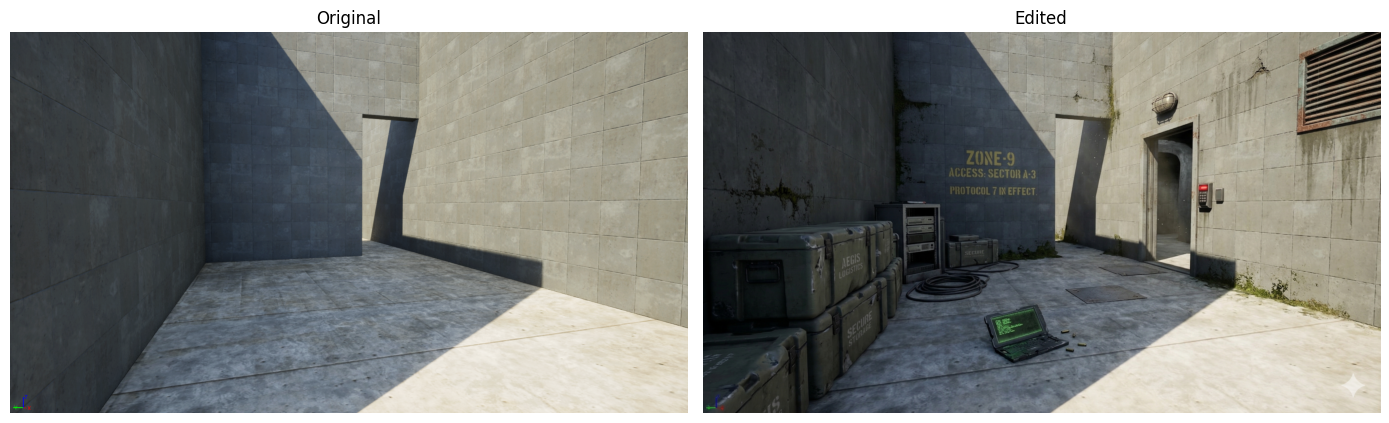

Working at 1526x858


In [12]:
def load_exr_rgb(path):
    exr = OpenEXR.InputFile(str(path))
    dw  = exr.header()['dataWindow']
    w, h = dw.max.x - dw.min.x + 1, dw.max.y - dw.min.y + 1
    flt = Imath.PixelType(Imath.PixelType.FLOAT)
    rgb = np.stack(
        [np.frombuffer(exr.channel(c, flt), np.float32).reshape(h, w) for c in 'RGB'],
        axis=-1)
    return Image.fromarray(np.clip(rgb * 255, 0, 255).astype(np.uint8))


def load_image(path):
    p = str(path)
    return load_exr_rgb(p) if p.lower().endswith('.exr') else Image.open(p).convert('RGB')


files       = os.listdir(DATA_DIR)
gt_rgb_path = next(DATA_DIR / f for f in files
                   if f.endswith('.exr') and 'depth' not in f.lower() and 'scenedepth' not in f.lower())
edited_path = next(DATA_DIR / f for f in files
                   if 'edit' in f.lower() and f.endswith(('.png', '.jpg', '.exr')))

original_img   = load_image(gt_rgb_path)
edited_img     = load_image(edited_path)
h_img, w_img   = np.array(original_img).shape[:2]
edited_resized = (edited_img.resize((w_img, h_img), Image.BILINEAR)
                  if edited_img.size != original_img.size else edited_img)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(original_img);   axes[0].set_title('Original');  axes[0].axis('off')
axes[1].imshow(edited_resized); axes[1].set_title('Edited');    axes[1].axis('off')
plt.tight_layout(); plt.show()
print(f'Working at {w_img}x{h_img}')


Loading DINOv2 on cuda ...


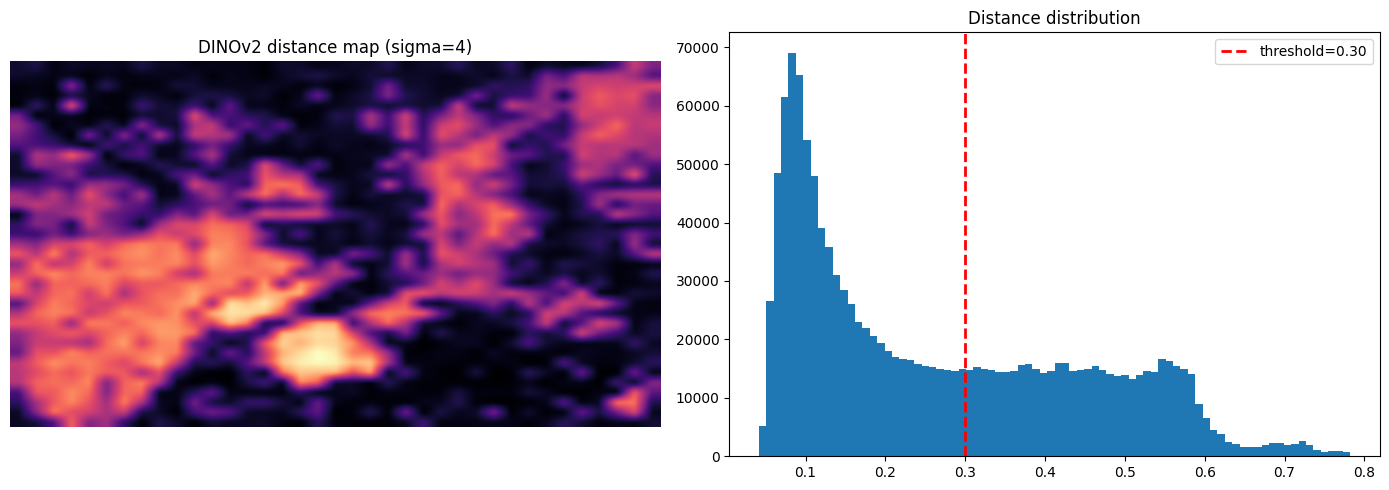

Raw map ready.  Patch grid: 37x37
Baseline config: threshold=0.30, sigma=4, min_area=500, dilate_iter=2


In [13]:
for _v in ('processor', 'model', 'inputs1', 'inputs2', 'outputs1', 'outputs2',
           'features1', 'features2', 'f1_norm', 'f2_norm', 'distance_map'):
    globals().pop(_v, None)
gc.collect()
if device == 'cuda':
    torch.cuda.empty_cache()

print(f'Loading DINOv2 on {device} ...')
processor = AutoImageProcessor.from_pretrained(
    DINO_MODEL_NAME,
    size={'height': 518, 'width': 518},
    crop_size={'height': 518, 'width': 518},
)
model = AutoModel.from_pretrained(DINO_MODEL_NAME).to(device).eval()
num_register = 4 if 'reg' in DINO_MODEL_NAME else 0

with torch.no_grad():
    inputs1 = processor(images=original_img, return_tensors='pt').to(device)
    inputs2 = processor(images=edited_resized, return_tensors='pt').to(device)

    outputs1 = model(**inputs1, output_hidden_states=True)
    outputs2 = model(**inputs2, output_hidden_states=True)

    skip = 1 + num_register
    selected1 = [outputs1.hidden_states[i][:, skip:, :] for i in [3, 6, 9, 12]]
    selected2 = [outputs2.hidden_states[i][:, skip:, :] for i in [3, 6, 9, 12]]
    features1 = torch.cat(selected1, dim=-1)
    features2 = torch.cat(selected2, dim=-1)

    f1_norm = features1 / features1.norm(dim=-1, keepdim=True)
    f2_norm = features2 / features2.norm(dim=-1, keepdim=True)
    distance = 1 - (f1_norm * f2_norm).sum(dim=-1).squeeze()

num_patches = distance.shape[0]
grid_size   = int(np.sqrt(num_patches))
distance_map = distance.reshape(1, 1, grid_size, grid_size)
RAW_DINO_DIFF = F.interpolate(
    distance_map, size=(h_img, w_img), mode='bilinear', align_corners=False
).squeeze().cpu().numpy()

from params import DINO_BASELINE
BASE_THR    = DINO_BASELINE['threshold']
BASE_SIGMA  = DINO_BASELINE['sigma']
BASE_AREA   = DINO_BASELINE['min_area']
BASE_DILATE = DINO_BASELINE['dilate_iter']
BASE_DIFF   = ndimage.gaussian_filter(RAW_DINO_DIFF, sigma=BASE_SIGMA)

del model, processor, inputs1, inputs2, outputs1, outputs2
if device == 'cuda':
    torch.cuda.empty_cache()
gc.collect()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(BASE_DIFF, cmap='magma')
axes[0].set_title(f'DINOv2 distance map (sigma={BASE_SIGMA})')
axes[0].axis('off')
axes[1].hist(BASE_DIFF.ravel(), bins=80)
axes[1].axvline(BASE_THR, color='r', ls='--', lw=2, label=f'threshold={BASE_THR:.2f}')
axes[1].set_title('Distance distribution')
axes[1].legend()
plt.tight_layout(); plt.show()

print(f'Raw map ready.  Patch grid: {grid_size}x{grid_size}')
print(f'Baseline config: threshold={BASE_THR:.2f}, sigma={BASE_SIGMA}, min_area={BASE_AREA}, dilate_iter={BASE_DILATE}')


In [14]:
def refine_mask(mask, min_area=500, dilate_iter=2):
    mask = mask.copy()
    labeled, num_features = ndimage.label(mask)
    for i in range(1, num_features + 1):
        if np.sum(labeled == i) < min_area:
            mask[labeled == i] = False
    if dilate_iter > 0:
        mask = ndimage.binary_dilation(mask, iterations=dilate_iter)
    mask = ndimage.binary_fill_holes(mask)
    return mask


def run_dinov2(diff_map, threshold, min_area, dilate_iter):
    init = diff_map > threshold
    refined = refine_mask(init, min_area=min_area, dilate_iter=dilate_iter)
    return refined, init


def show_sweep(results, title, cols=4):
    names = list(results.keys())
    n     = len(names)
    rows  = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    axes_flat = axes.flatten() if rows > 1 else np.atleast_1d(axes)
    for i, name in enumerate(names):
        mask = results[name]
        ov = np.zeros((h_img, w_img, 4), dtype=np.float32)
        ov[mask] = [1, 0, 0, 0.50]
        axes_flat[i].imshow(edited_resized)
        axes_flat[i].imshow(ov)
        axes_flat[i].set_title(f'{name}\n{mask.mean()*100:.1f}% changed', fontsize=10)
        axes_flat[i].axis('off')
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].axis('off')
    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()


## Sweep 1 - `threshold`

The most important parameter. Other params held at a balanced base:
`sigma=4`, `min_area=500`, `dilate_iter=2`.


[1/7] thr=0.15 ...
       init=61.5%  changed=63.4%
[2/7] thr=0.20 ...
       init=52.2%  changed=53.8%
[3/7] thr=0.25 ...
       init=45.4%  changed=47.1%
[4/7] thr=0.30 ...
       init=39.2%  changed=40.8%
[5/7] thr=0.35 ...
       init=33.1%  changed=34.5%
[6/7] thr=0.40 ...
       init=26.9%  changed=28.3%
[7/7] thr=0.50 ...
       init=14.7%  changed=15.8%


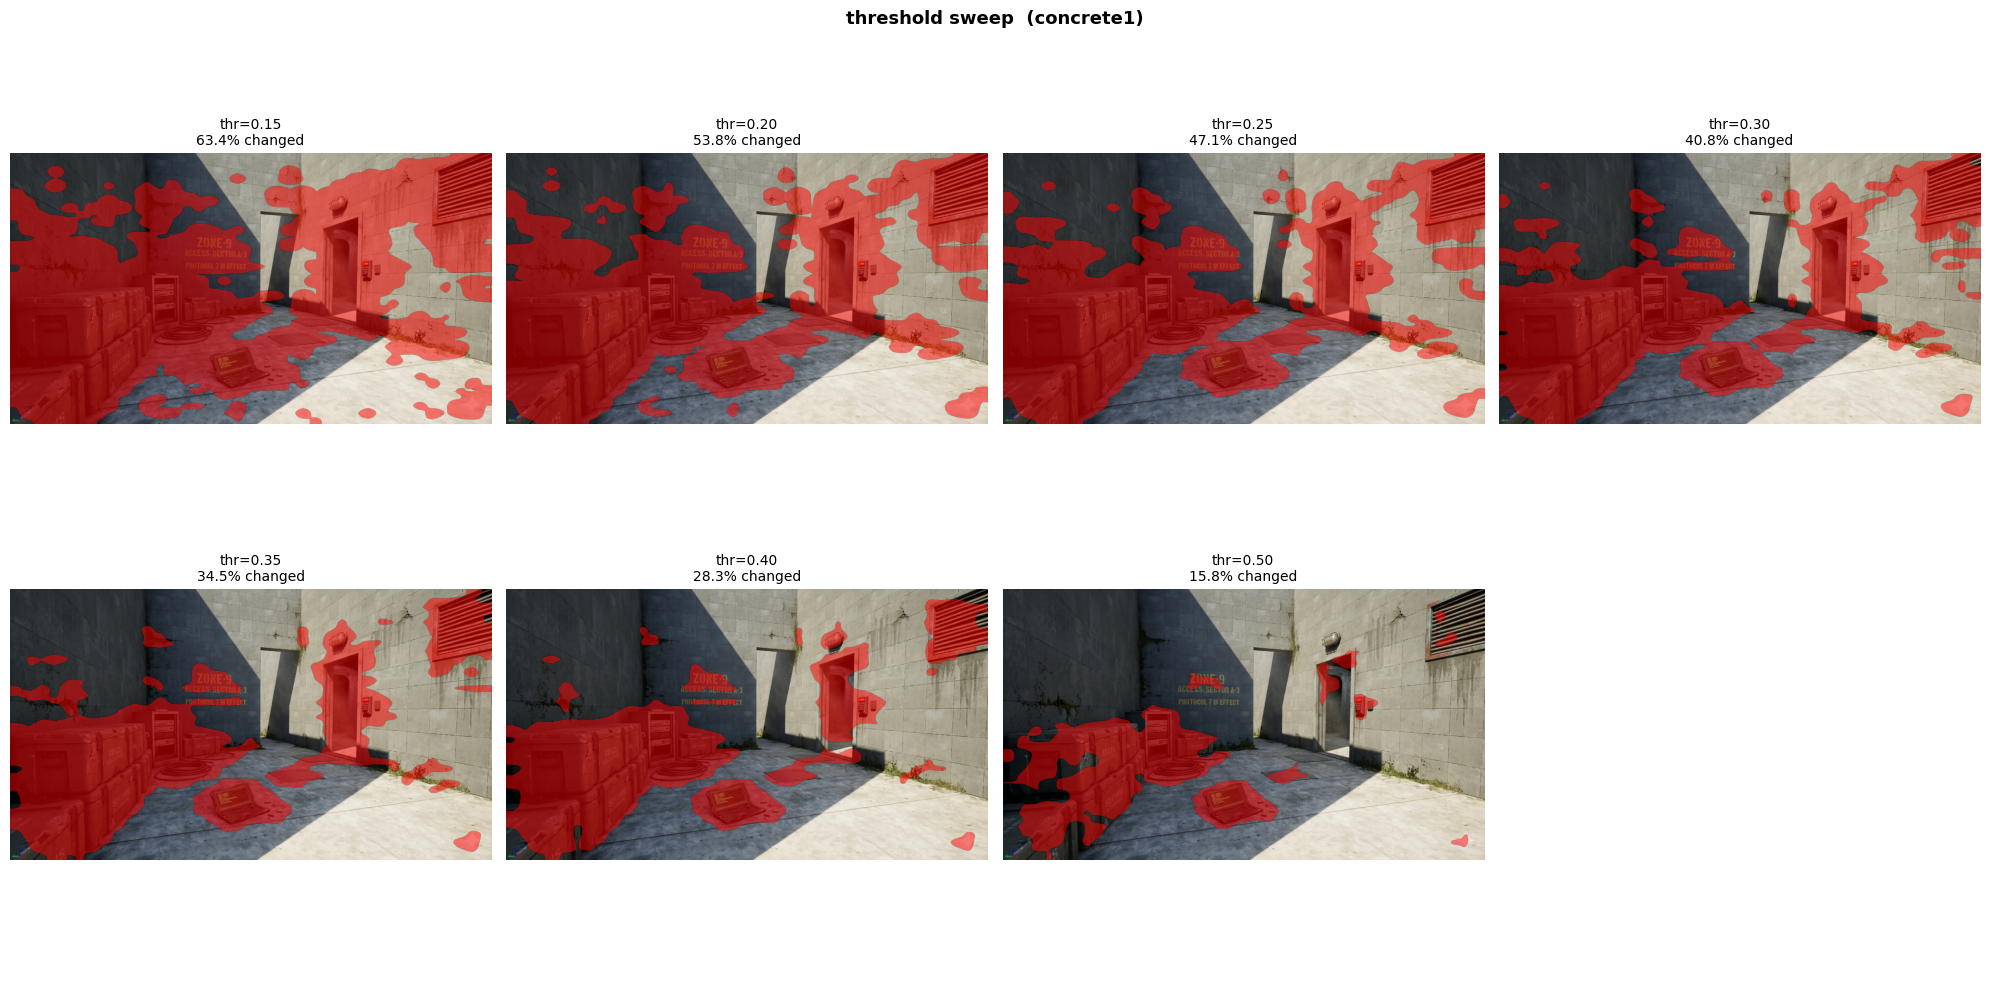

In [15]:
thr_values = [0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]

thr_results = {}
for i, v in enumerate(thr_values, 1):
    name = f'thr={v:.2f}'
    print(f'[{i}/{len(thr_values)}] {name} ...', flush=True)
    refined, init = run_dinov2(BASE_DIFF, threshold=v, min_area=BASE_AREA, dilate_iter=BASE_DILATE)
    thr_results[name] = refined
    print(f'       init={init.mean()*100:.1f}%  changed={refined.mean()*100:.1f}%')

show_sweep(thr_results, f'threshold sweep  ({DATASET})', cols=4)


## Sweep 2 - `sigma`

Other params: `threshold=0.30`, `min_area=500`, `dilate_iter=2`.
This re-smooths the cached raw DINOv2 distance map, so it stays cheap.


[1/6] sigma=0 ...
       init=39.3%  changed=40.9%
[2/6] sigma=1 ...
       init=39.3%  changed=40.8%
[3/6] sigma=2 ...
       init=39.2%  changed=40.8%
[4/6] sigma=4 ...
       init=39.2%  changed=40.8%
[5/6] sigma=6 ...
       init=39.1%  changed=40.6%
[6/6] sigma=8 ...
       init=39.0%  changed=40.3%


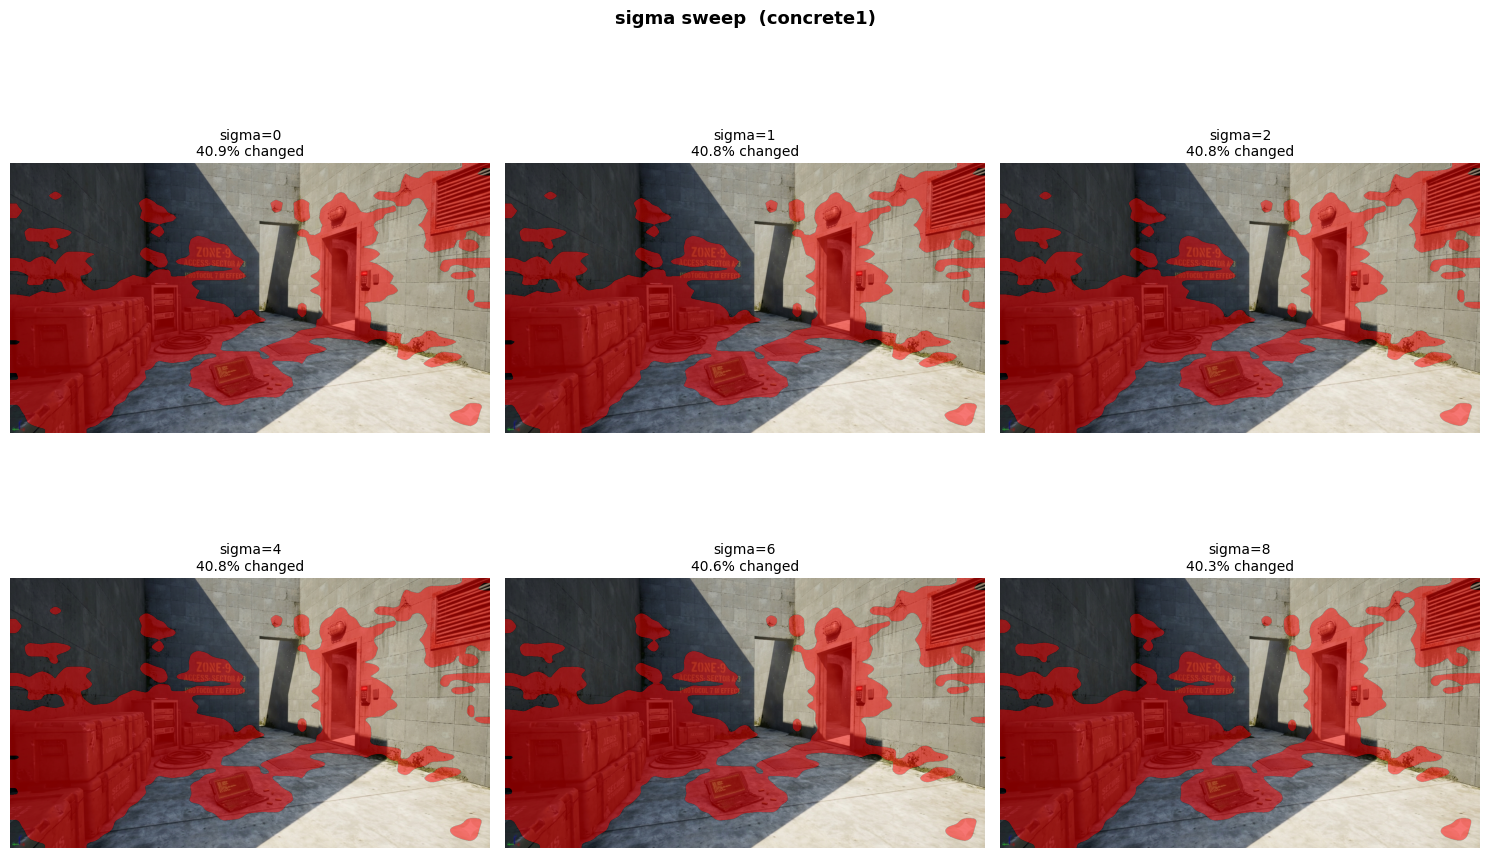

In [16]:
sigma_values = [0, 1, 2, 4, 6, 8]

sigma_results = {}
for i, v in enumerate(sigma_values, 1):
    name = f'sigma={v}'
    print(f'[{i}/{len(sigma_values)}] {name} ...', flush=True)
    diff_map = ndimage.gaussian_filter(RAW_DINO_DIFF, sigma=v) if v > 0 else RAW_DINO_DIFF.copy()
    refined, init = run_dinov2(diff_map, threshold=BASE_THR, min_area=BASE_AREA, dilate_iter=BASE_DILATE)
    sigma_results[name] = refined
    print(f'       init={init.mean()*100:.1f}%  changed={refined.mean()*100:.1f}%')

show_sweep(sigma_results, f'sigma sweep  ({DATASET})', cols=3)


## Sweep 3 - `min_area`

Other params: `threshold=0.30`, `sigma=4`, `dilate_iter=2`.


[1/6] min_area=50 ...
       init=39.2%  changed=40.9%
[2/6] min_area=100 ...
       init=39.2%  changed=40.9%
[3/6] min_area=200 ...
       init=39.2%  changed=40.9%
[4/6] min_area=500 ...
       init=39.2%  changed=40.8%
[5/6] min_area=1000 ...
       init=39.2%  changed=40.4%
[6/6] min_area=2000 ...
       init=39.2%  changed=40.1%


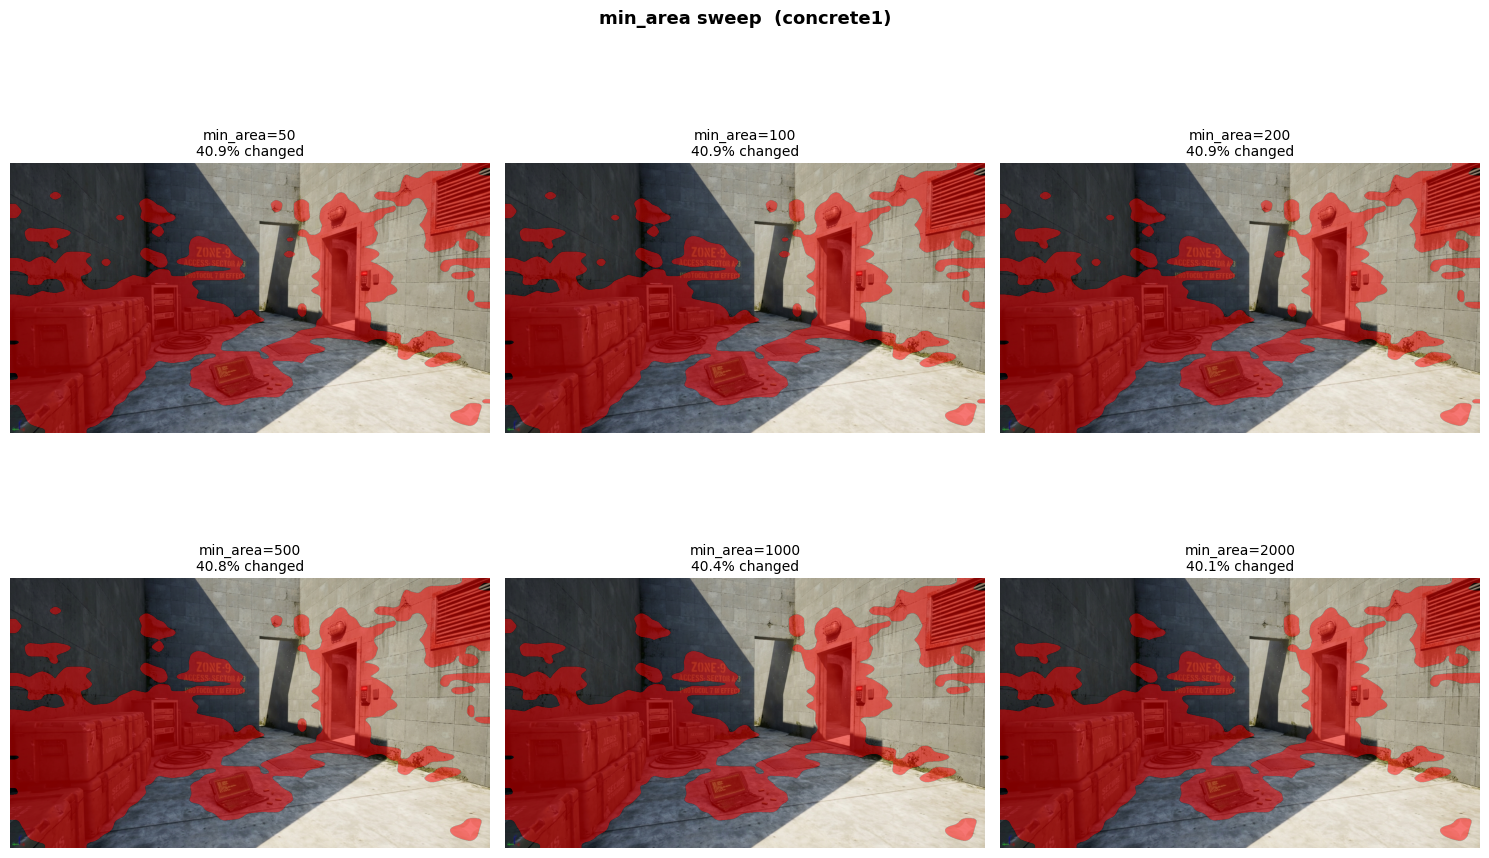

In [17]:
area_values = [50, 100, 200, 500, 1000, 2000]

area_results = {}
for i, v in enumerate(area_values, 1):
    name = f'min_area={v}'
    print(f'[{i}/{len(area_values)}] {name} ...', flush=True)
    refined, init = run_dinov2(BASE_DIFF, threshold=BASE_THR, min_area=v, dilate_iter=BASE_DILATE)
    area_results[name] = refined
    print(f'       init={init.mean()*100:.1f}%  changed={refined.mean()*100:.1f}%')

show_sweep(area_results, f'min_area sweep  ({DATASET})', cols=3)


## Sweep 4 - `dilate_iter`

Other params: `threshold=0.30`, `sigma=4`, `min_area=500`.


[1/6] dilate=0 ...
       init=39.2%  changed=39.2%
[2/6] dilate=1 ...
       init=39.2%  changed=40.0%
[3/6] dilate=2 ...
       init=39.2%  changed=40.8%
[4/6] dilate=3 ...
       init=39.2%  changed=41.5%
[5/6] dilate=4 ...
       init=39.2%  changed=42.3%
[6/6] dilate=6 ...
       init=39.2%  changed=43.8%


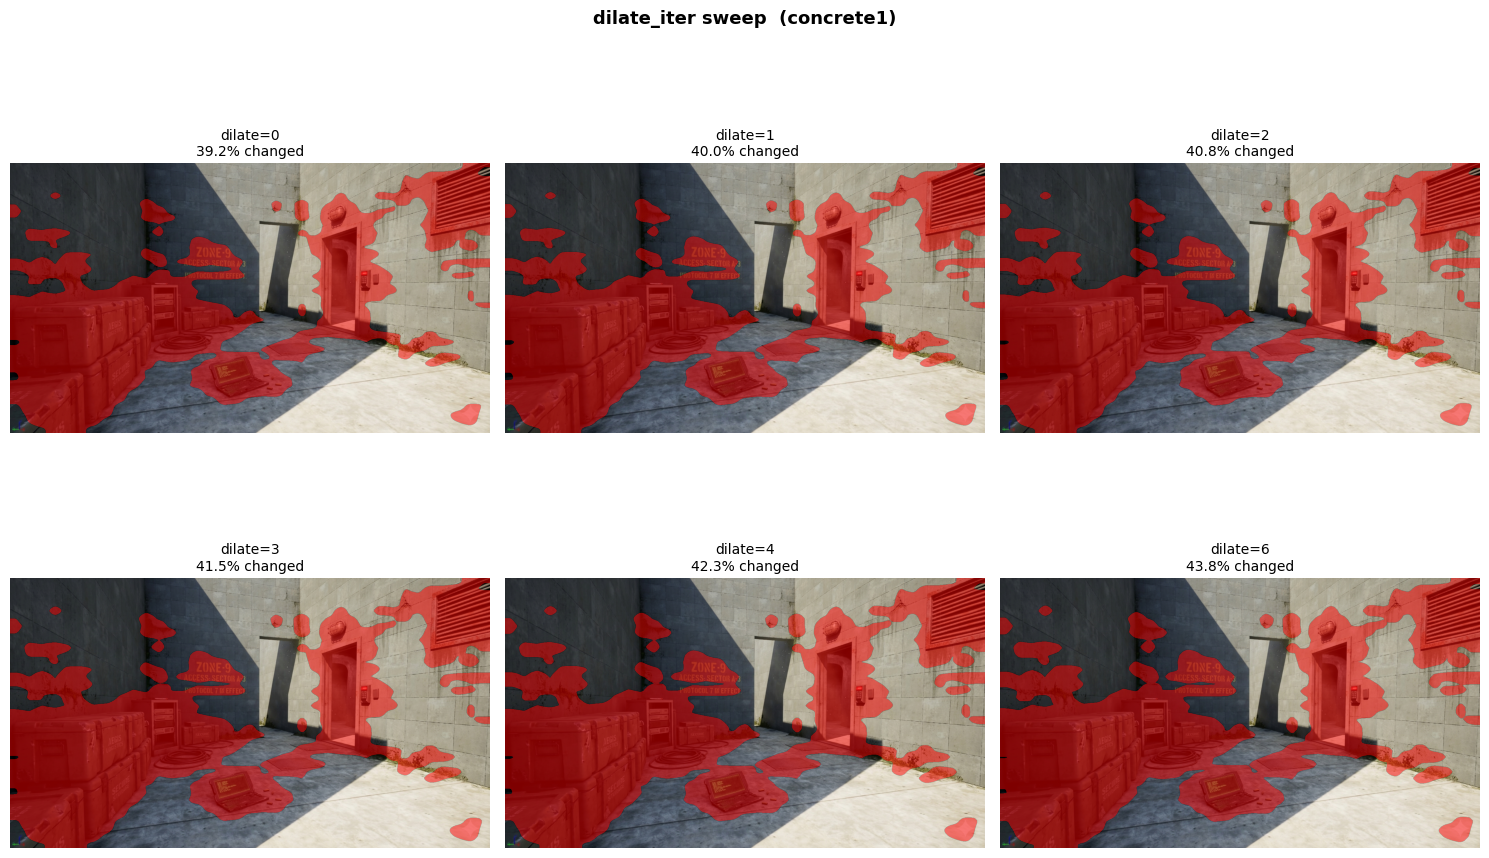

In [18]:
dilate_values = [0, 1, 2, 3, 4, 6]

dilate_results = {}
for i, v in enumerate(dilate_values, 1):
    name = f'dilate={v}'
    print(f'[{i}/{len(dilate_values)}] {name} ...', flush=True)
    refined, init = run_dinov2(BASE_DIFF, threshold=BASE_THR, min_area=BASE_AREA, dilate_iter=v)
    dilate_results[name] = refined
    print(f'       init={init.mean()*100:.1f}%  changed={refined.mean()*100:.1f}%')

show_sweep(dilate_results, f'dilate_iter sweep  ({DATASET})', cols=3)


## Combos

Fill in your preferred values from the sweeps above and compare them head-to-head.


[1/4] baseline ...
       sigma=4  thr=0.30  min_area=500  dilate=2
       init=39.2%  changed=40.8%
[2/4] candidate_1 ...
       sigma=4  thr=0.25  min_area=500  dilate=2
       init=45.4%  changed=47.1%
[3/4] candidate_2 ...
       sigma=2  thr=0.25  min_area=200  dilate=1
       init=45.4%  changed=46.6%
[4/4] candidate_3 ...
       sigma=6  thr=0.35  min_area=1000  dilate=3
       init=32.9%  changed=34.7%


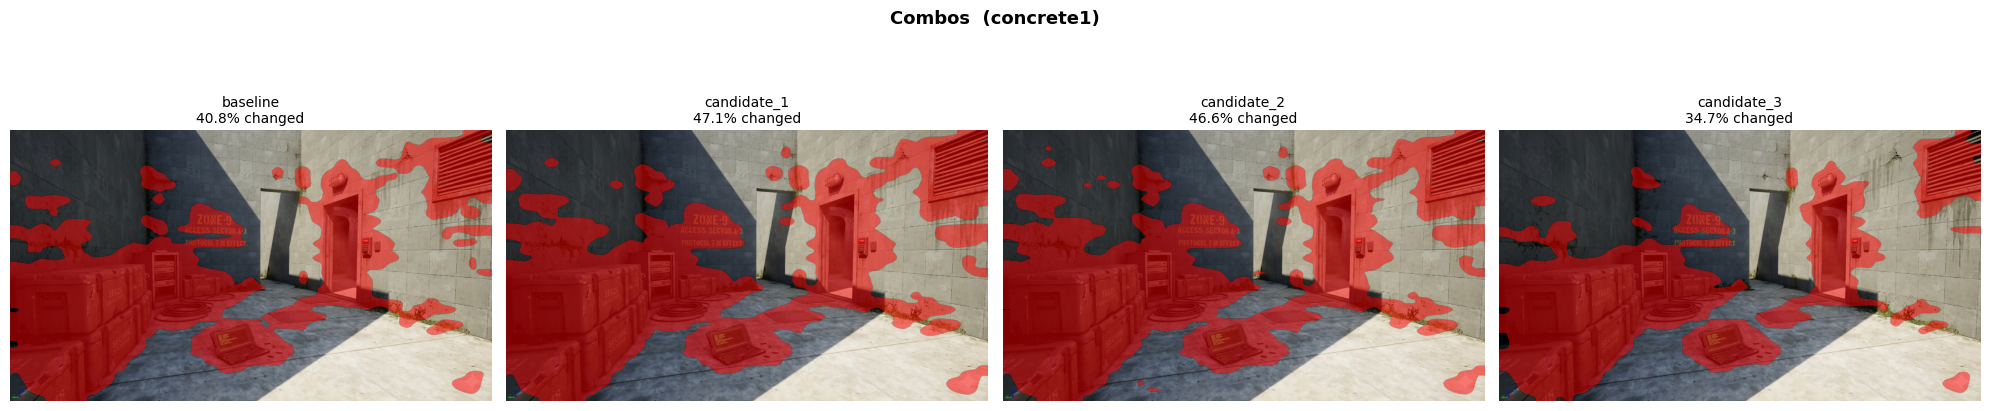

In [19]:
combo_configs = {
    'baseline': dict(**DINO_BASELINE),
    # <- edit these with your preferred values from the sweeps above
    'candidate_1': dict(threshold=0.25, min_area=500, dilate_iter=2, sigma=4),
    'candidate_2': dict(threshold=0.25, min_area=200, dilate_iter=1, sigma=2),
    'candidate_3': dict(threshold=0.35, min_area=1000, dilate_iter=3, sigma=6),
}

combo_results = {}
for i, (name, cfg) in enumerate(combo_configs.items(), 1):
    print(f'[{i}/{len(combo_configs)}] {name} ...', flush=True)
    diff_map = ndimage.gaussian_filter(RAW_DINO_DIFF, sigma=cfg['sigma']) if cfg['sigma'] > 0 else RAW_DINO_DIFF.copy()
    refined, init = run_dinov2(
        diff_map,
        threshold=cfg['threshold'],
        min_area=cfg['min_area'],
        dilate_iter=cfg['dilate_iter'],
    )
    combo_results[name] = refined
    print(f"       sigma={cfg['sigma']}  thr={cfg['threshold']:.2f}  min_area={cfg['min_area']}  dilate={cfg['dilate_iter']}")
    print(f'       init={init.mean()*100:.1f}%  changed={refined.mean()*100:.1f}%')

show_sweep(combo_results, f'Combos  ({DATASET})', cols=4)


In [20]:
gc.collect()
if device == 'cuda':
    torch.cuda.empty_cache()
print('Done.')


Done.
